<a href="https://colab.research.google.com/github/OkyereBiew/bayesian-credit-risk-simulator/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pymc arviz

In [3]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries installed successfully")

All libraries installed successfully


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
column_names = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_duration",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_duration",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

In [6]:
df = pd.read_csv(
    "german.data",
    sep=" ",
    header=None,
    names=column_names
)

df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 21)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_duration       1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [9]:
target_counts = df["target"].value_counts()

print(target_counts)

target
1    700
2    300
Name: count, dtype: int64


In [10]:
df["risk_label"] = df["target"].map({
    1: "Good Credit",
    2: "Bad Credit"
})

df[["target", "risk_label"]].head()

,target,risk_label
0,1,Good Credit
1,2,Bad Credit
2,1,Good Credit
3,1,Good Credit
4,2,Bad Credit


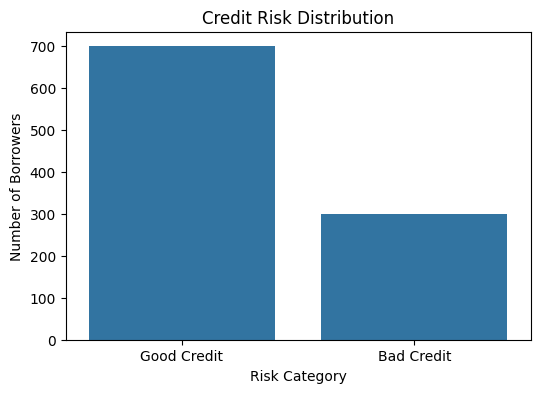

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="risk_label"
)

plt.title("Credit Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Borrowers")

plt.show()

## Observation

The dataset contains more good-credit borrowers than bad-credit borrowers. This indicates class imbalance, which is common in real-world credit risk datasets because defaults are relatively rare events.

This imbalance is important when building probabilistic credit risk models because the model must correctly identify risky borrowers without being biased toward the majority class.

In [12]:
df.describe()

,duration,credit_amount,installment_rate,residence_duration,age,existing_credits,people_liable,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


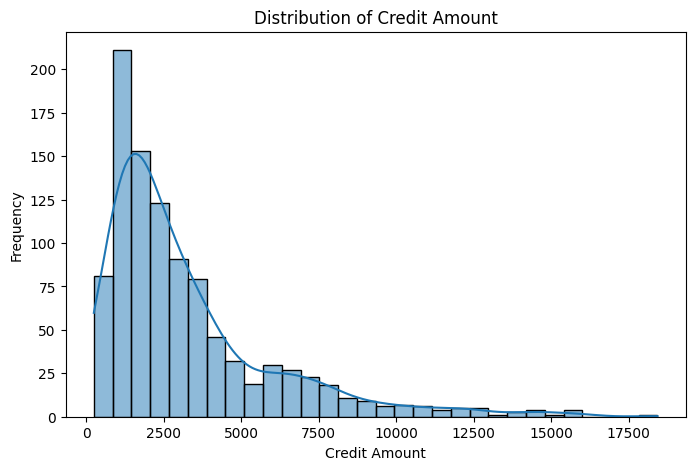

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["credit_amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

## Credit Amount Insight

The distribution of credit amount appears right-skewed, indicating that most borrowers request relatively smaller loans while a smaller number of borrowers request very large loan amounts.

This type of skewness is common in financial datasets and may influence risk behavior and model assumptions.

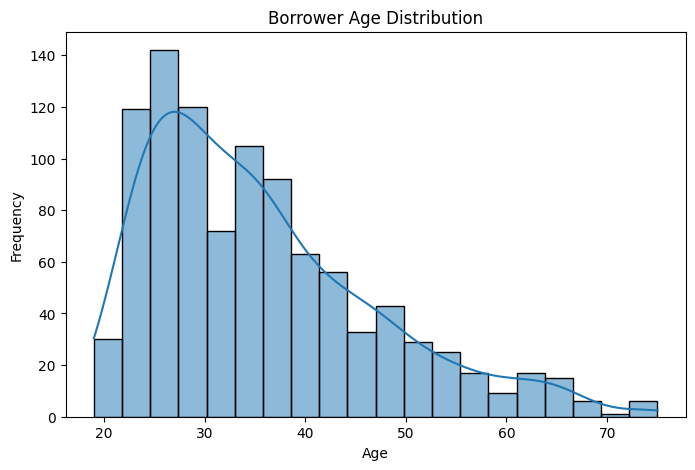

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Borrower Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

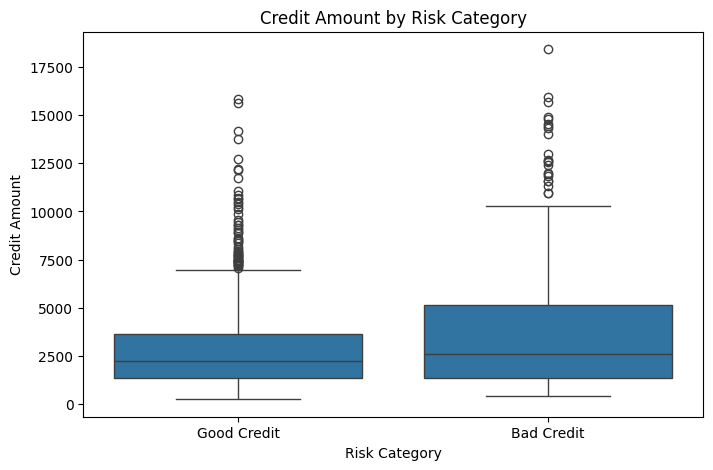

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="risk_label",
    y="credit_amount"
)

plt.title("Credit Amount by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Credit Amount")

plt.show()

## Risk vs Credit Amount

The boxplot compares loan amounts across borrower risk categories. Differences in the distributions may indicate that loan size is associated with repayment risk.

This relationship is important in credit risk modeling because larger loans may expose lenders to higher potential losses.

In [16]:
df.isnull().sum()

,0
checking_account,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_account,0
employment_duration,0
installment_rate,0
personal_status_sex,0
other_debtors,0
